In [1]:
from neuro_data.static_images import data_schemas, configs
from staticnet_experiments import models, configs
from staticnet_experiments.configs import NetworkConfig, DataConfig, CoreConfig, ReadoutConfig, ModulatorConfig, ShifterConfig, TrainConfig
from staticnet_experiments.models import *
from staticnet_analyses import multi_mei, utils, closed_loop
from neuro_data.static_images.data_schemas import stimulus

import datajoint as dj
dj.config['display.limit'] = 30
import torch
from torch.optim import SGD
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

from torch.autograd import Variable, variable

import seaborn as sns
from neuro_data.static_images import stats
import datajoint as dj

from itertools import zip_longest

def grouper(n, iterable, fillvalue=None):
    "grouper(3, 'ABCDEFG', 'x') --> ABC DEF Gxx"
    args = [iter(iterable)] * n
    return zip_longest(fillvalue=fillvalue, *args)

from itertools import count

import datajoint as dj

Connecting eywalker@10.28.0.34:3306
loaded!


/src/static-networks/staticnet_analyses/multi_mei.py:1666: UserWarning: Use of this table is deprecated. It is kept only for record keeping purpose
  warnings.warn('Use of this table is deprecated. It is kept only for record keeping purpose')


In [8]:
stimulus.StaticImage.TightMaskedMEI.heading

# 
image_class          : varchar(16)                  # 
image_id             : int                          # image id
---
group_id             : smallint                     # index of group
net_hash             : varchar(256)                 # unique identifier for configuration
seed                 : int                          # random seed
mei_param_id         : varchar(64)                  # id
data_hash            : varchar(256)                 # unique identifier for configuration
readout_key          : varchar(128)                 # 
neuron_id            : smallint                     # 
tight_mask_param_id  : int                          # 
img_config_id        : int                          # 
src_table            : varchar(64)                  # table with corresponding entry

In [40]:
group_id = 22

# Fill out StaticImage with a new stimulus sizes

In [3]:
for c in ['cnn_mei', 'lin_rf', 'multi_cnn_mei', 'multi_lin_rf']:
    stimulus.StaticImage().insert1((c, 256, 144, 0), skip_duplicates=True)

# Fill out StaticImage.Image and StaticImage.MEI

In [4]:
closed_loop.fill_multi_mei_stimulus(group_id=group_id)

Creating image ID 5400
Creating image ID 5401
Creating image ID 5402
Creating image ID 5403
Creating image ID 5404
Creating image ID 5405
Creating image ID 5406
Creating image ID 5407
Creating image ID 5408
Creating image ID 5409
Creating image ID 5410
Creating image ID 5411
Creating image ID 5412
Creating image ID 5413
Creating image ID 5414
Creating image ID 5415
Creating image ID 5416
Creating image ID 5417
Creating image ID 5418
Creating image ID 5419
Creating image ID 5420
Creating image ID 5421
Creating image ID 5422
Creating image ID 5423
Creating image ID 5424
Creating image ID 5425
Creating image ID 5426
Creating image ID 5427
Creating image ID 5428
Creating image ID 5429
Creating image ID 5430
Creating image ID 5431
Creating image ID 5432
Creating image ID 5433
Creating image ID 5434
Creating image ID 5435
Creating image ID 5436
Creating image ID 5437
Creating image ID 5438
Creating image ID 5439
Creating image ID 5440
Creating image ID 5441
Creating image ID 5442
Creating im

In [5]:
stimulus.StaticImage.Image & (stimulus.StaticImage.MultiMEI & 'group_id = {}'.format(group_id))

image_class,image_id image id,image actual image
multi_cnn_mei,5400,=BLOB=
multi_cnn_mei,5401,=BLOB=
multi_cnn_mei,5402,=BLOB=
multi_cnn_mei,5403,=BLOB=
multi_cnn_mei,5404,=BLOB=
multi_cnn_mei,5405,=BLOB=
multi_cnn_mei,5406,=BLOB=
multi_cnn_mei,5407,=BLOB=
multi_cnn_mei,5408,=BLOB=
multi_cnn_mei,5409,=BLOB=


# Set the current MEI stimulus target

In [6]:
stimulus.TargetStaticGroupID().delete()

About to delete:
`pipeline_stimulus`.`target_static_group_i_d`: 1 items
Committed.


In [7]:
stimulus.TargetStaticGroupID.insert1((group_id,))

In [8]:
stimulus.TargetStaticGroupID()

group_id Target group id to run stimulus for
22


# Visualize the stimulus

In [29]:
group_id = 22

In [30]:
group_images = stimulus.StaticImage.MultiMEI & 'group_id = {}'.format(group_id)

In [31]:
images = (stimulus.StaticImage.Image & group_images & 'image_class = "multi_cnn_mei"').fetch('image', order_by='image_id')

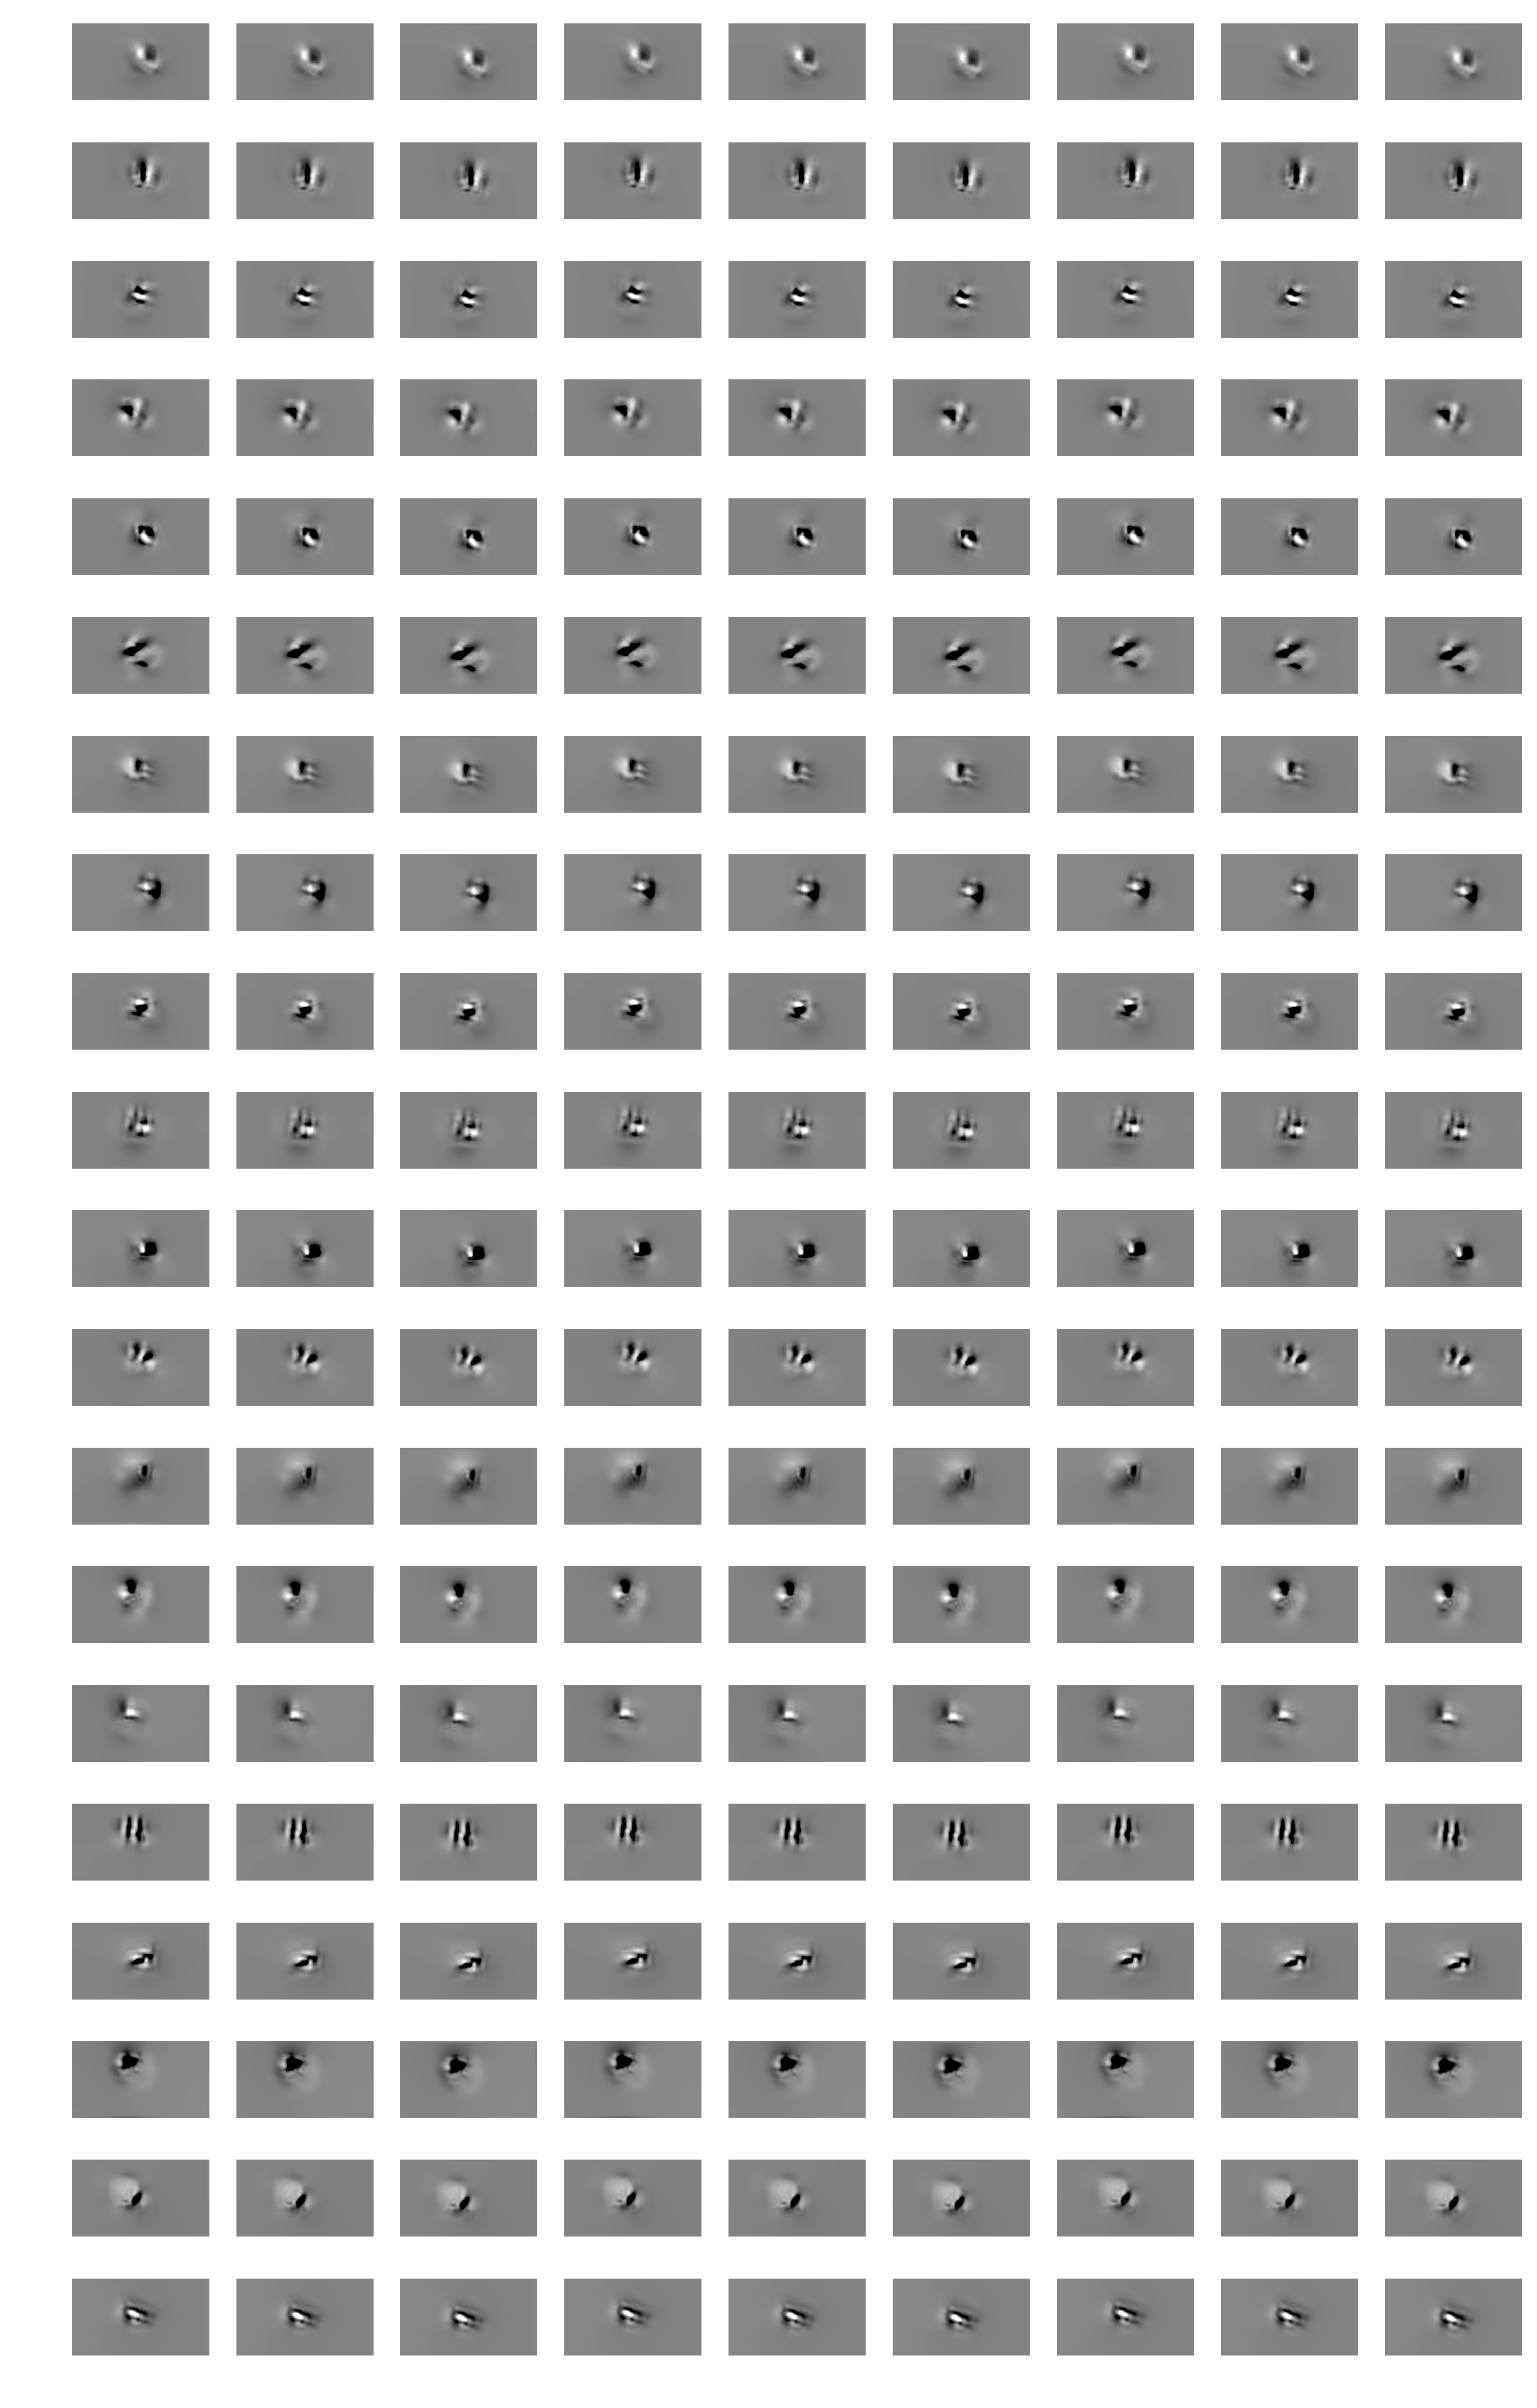

In [32]:
fig, axs = plt.subplots(20, 9, dpi=300, figsize=(12, 20))
[ax.axis('off') for ax in axs.ravel()]
for ax, img in zip(axs.ravel(), images):
    assert img.shape == (144, 256), 'Wrong size!'
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)

In [33]:
images = (stimulus.StaticImage.Image & group_images & 'image_class = "multi_lin_rf"').fetch('image', order_by='image_id')

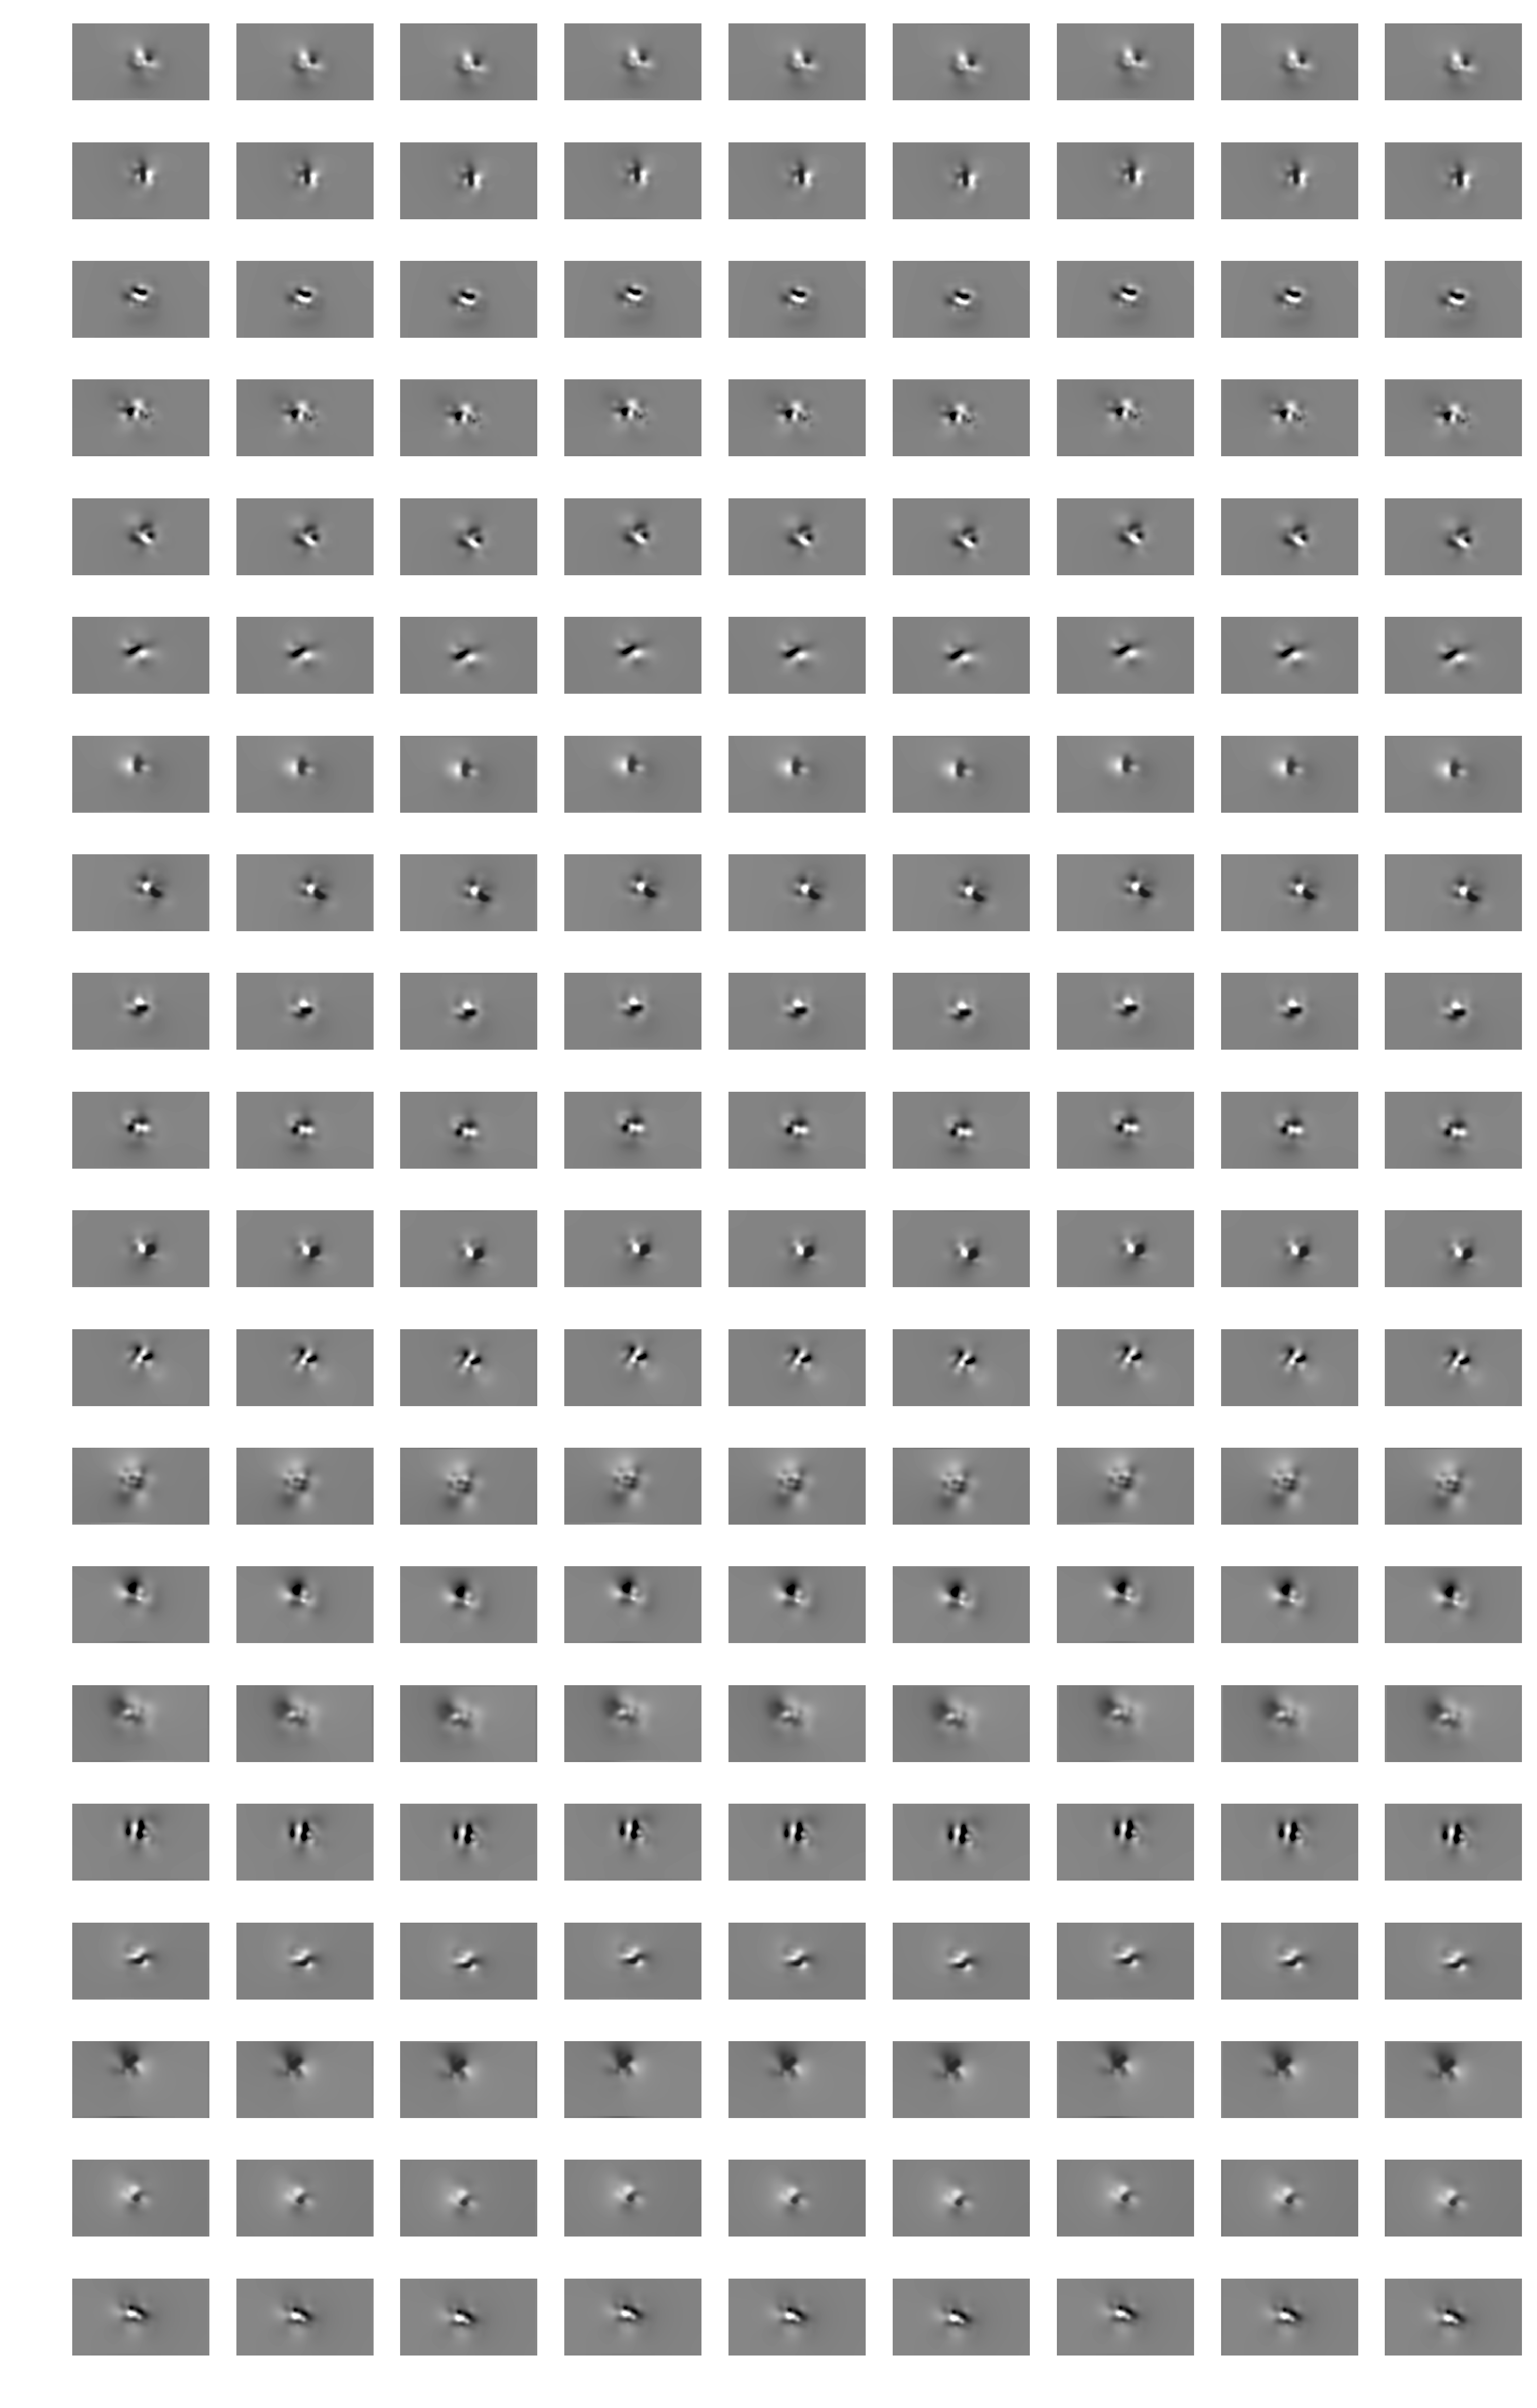

In [34]:
fig, axs = plt.subplots(20, 9, dpi=300, figsize=(12, 20))
[ax.axis('off') for ax in axs.ravel()]
for ax, img in zip(axs.ravel(), images):
    assert img.shape == (144, 256), 'Wrong size!'
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)

In [35]:
cnn_mei = (stimulus.StaticImage.Image & (stimulus.StaticImage.MultiMEI & 'x_shift=0 and y_shift=0') & group_images & 'image_class = "multi_cnn_mei"')
lin_rf = (stimulus.StaticImage.Image & (stimulus.StaticImage.MultiMEI & 'x_shift=0 and y_shift=0') & group_images & 'image_class = "multi_lin_rf"')

In [36]:
combo = cnn_mei.proj(mei_img='image', mei_class='image_class') * lin_rf.proj(rf_img='image', rf_class='image_class')

In [37]:
mei_images, rf_images = combo.fetch('mei_img', 'rf_img', order_by='image_id')

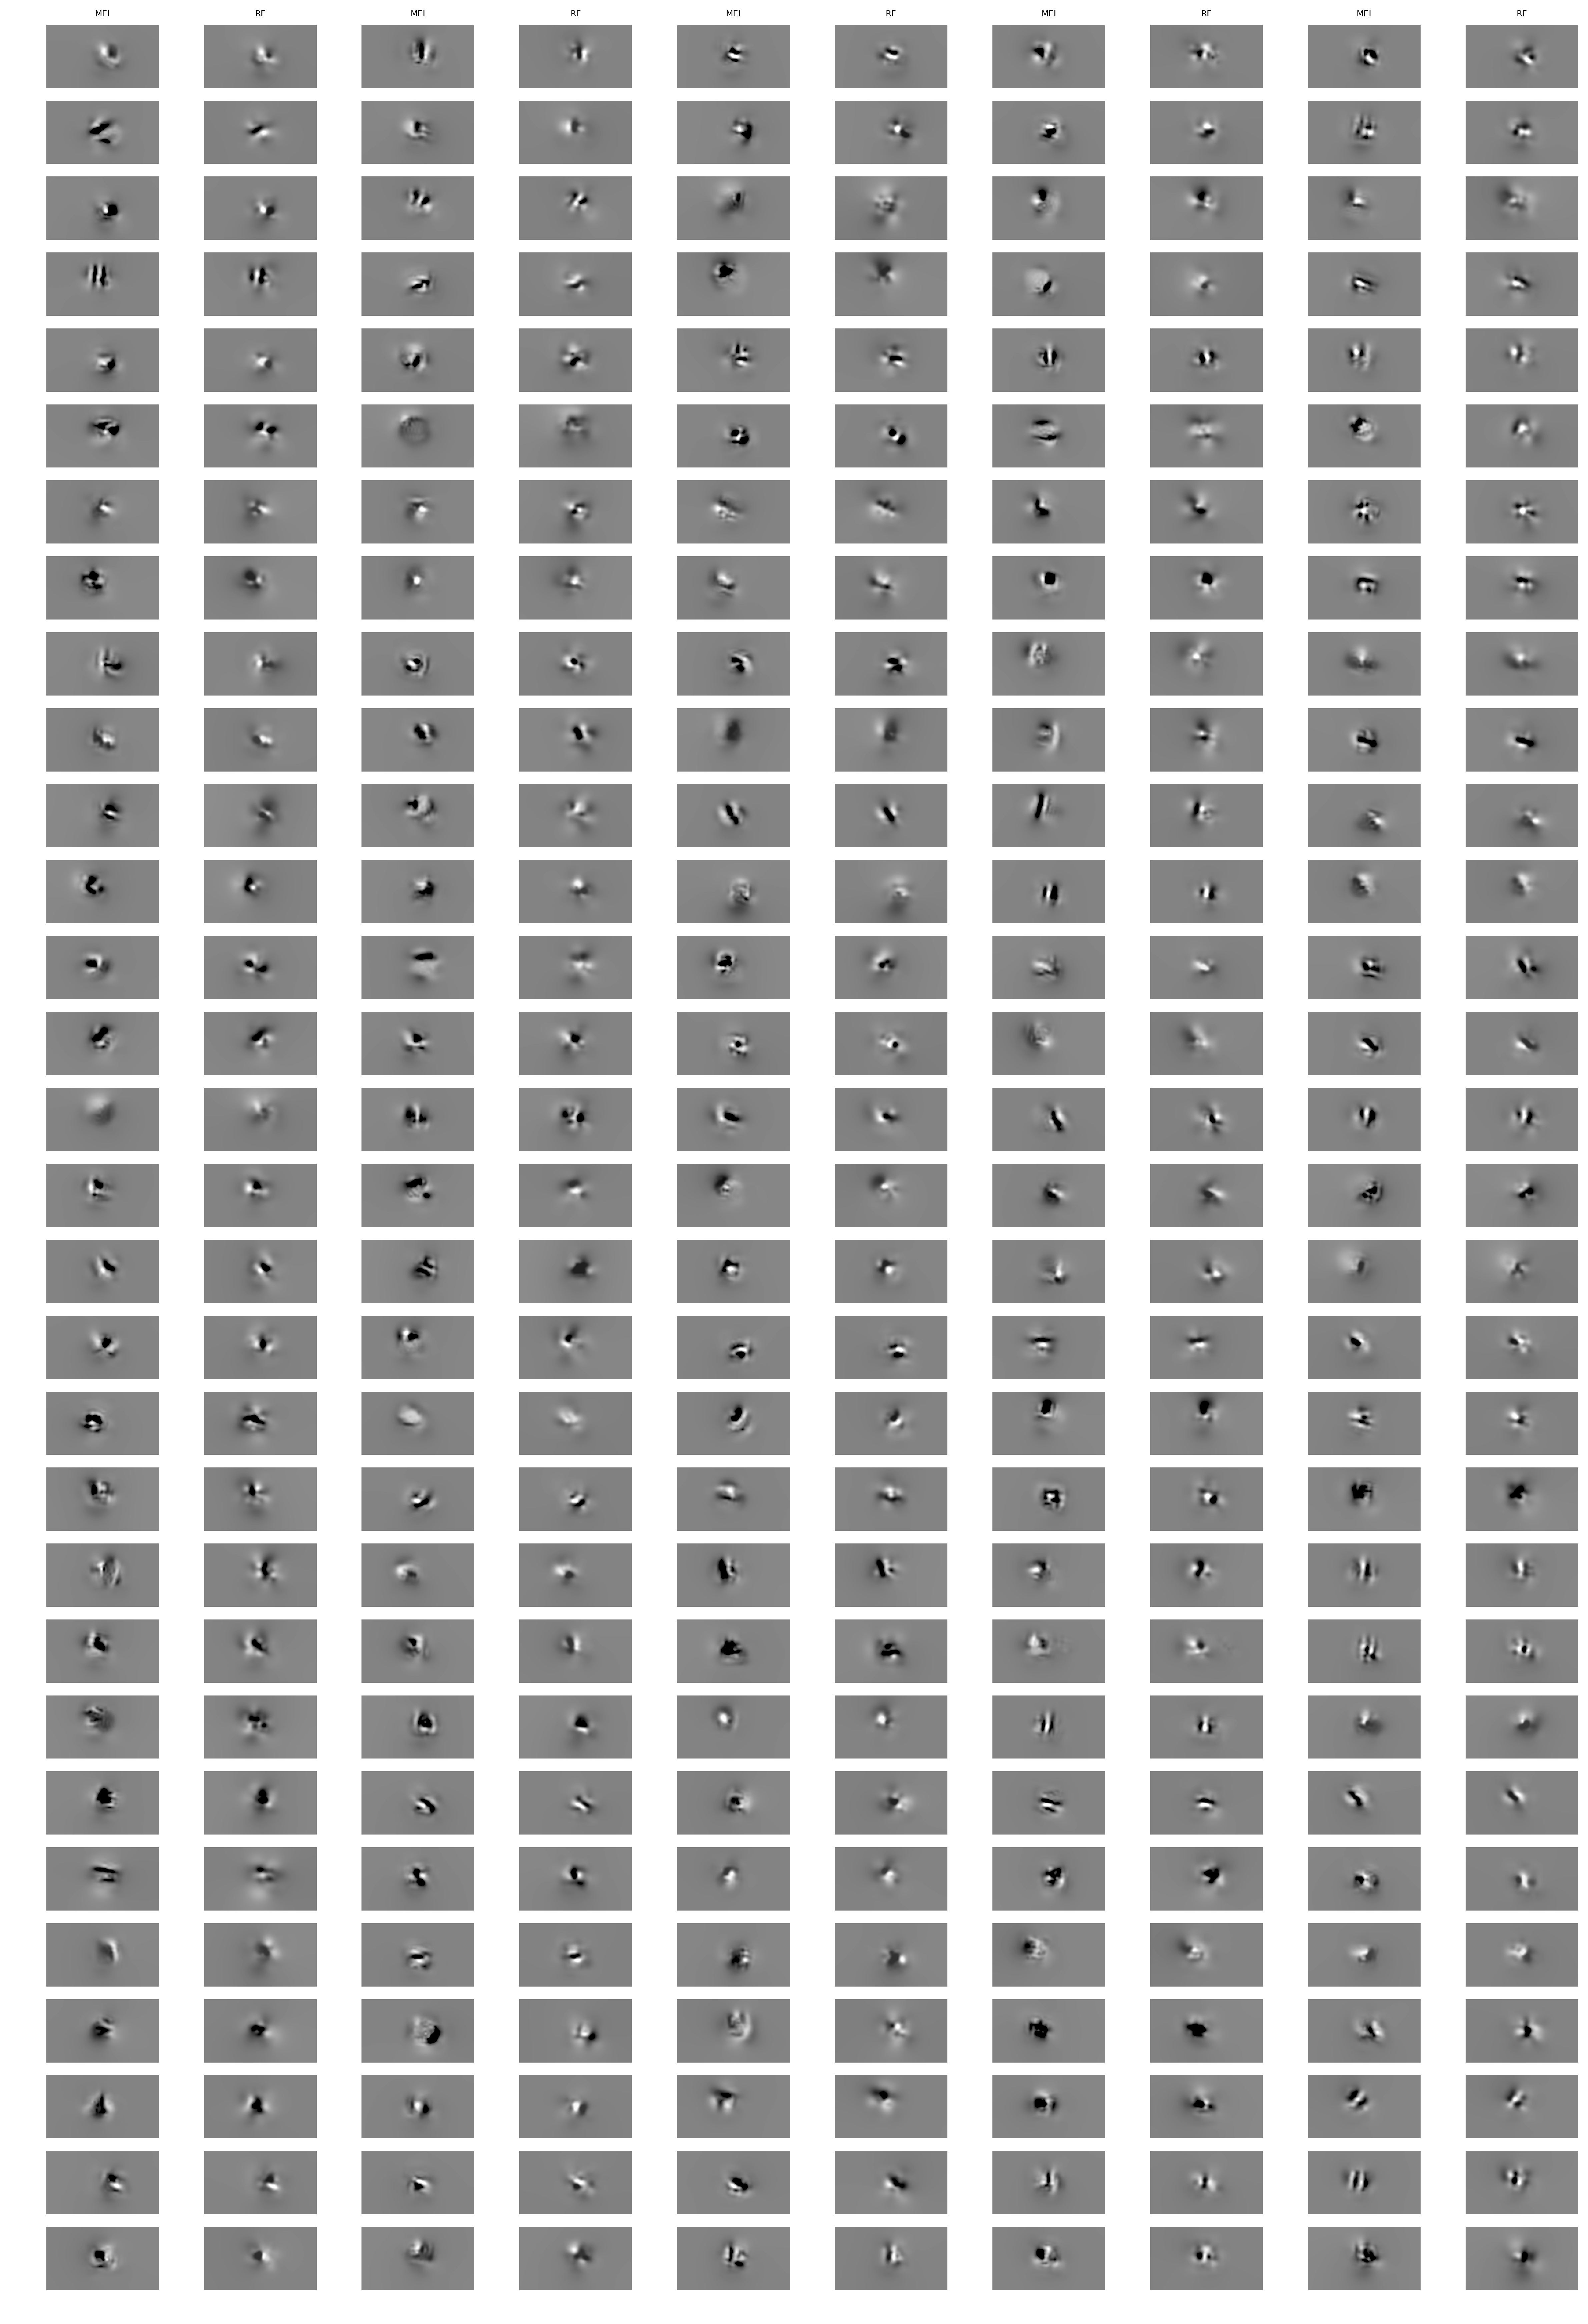

In [38]:
N = len(mei_images)
batch = 5
fig, axs = plt.subplots(int(N / batch), batch * 2, figsize=(4 * batch, N / batch), dpi=300)
axs = axs.reshape(-1, 2)

for row_idx, ax_row, *images in zip(count(), axs, mei_images, rf_images):
    for ax, img, label in zip(ax_row, images, ['MEI', 'RF']):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if row_idx < batch:
            ax.set_title(label, fontsize=6)